**This notebook visualizes flood risk**

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import rioxarray as rxr
import os

In [42]:
# https://gda-wi26-jupyterbook.readthedocs.io/en/latest/modules/06_Raster2/06_demo.html
gh_dem_fn = "/home/opana/gda_course_2026v/projects/local_project_folder/processed_data_for_flooding/grays_harbor_dem_resampled.tif"

In [43]:
gh_dem_da = rxr.open_rasterio(gh_dem_fn, masked=True).squeeze()
gh_dem_da

<xarray.DataArray (y: 8327, x: 9555)> Size: 318MB
[79564485 values with dtype=float32]
Coordinates:
  * y            (y) float64 67kB 5.265e+06 5.265e+06 ... 5.182e+06 5.182e+06
  * x            (x) float64 76kB 3.924e+05 3.924e+05 ... 4.879e+05 4.879e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [44]:
water_level = 2.0  # meters above NAVD88
flood_mask = arr < water_level

In [45]:

extent = (392404, 487954, 5182106, 5265376)
flood_depth = np.where(arr < water_level, water_level - arr, 0)

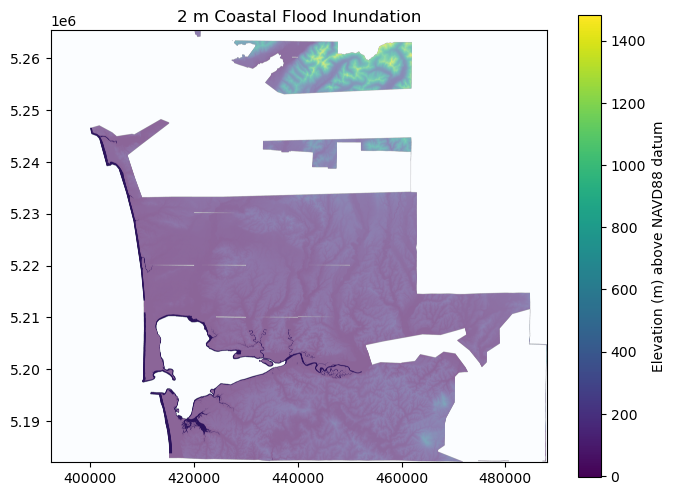

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

#ax.imshow(gray_harbor_hs_da, cmap="gray", extent=extent, origin="upper")

im = ax.imshow(arr, cmap="viridis", extent=extent, origin="upper")
fig.colorbar(im, ax=ax, label="Elevation (m) above NAVD88 datum")

# 2 m flood overlay
ax.imshow(flood_mask, cmap="Blues", alpha=0.4, extent=extent, origin="upper")

ax.set_title("2 m Coastal Flood Inundation")
plt.show()

In [37]:
# Convert elevation data to feet
arr_feet = arr * 3.28084

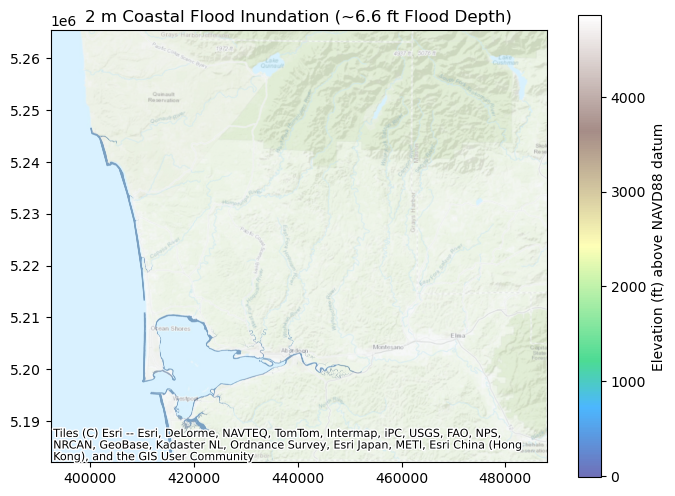

In [46]:
# Code generated by Copilot AI

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(arr_feet, cmap="terrain", extent=extent, origin="upper", alpha=0.7)
fig.colorbar(im, ax=ax, label="Elevation (ft) above NAVD88 datum")


ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldTopoMap,
    crs=26910
)

ax.imshow(flood_mask, cmap="Blues", alpha=0.4, extent=extent, origin="upper")

ax.set_title("2 m Coastal Flood Inundation (~6.6 ft Flood Depth)")
plt.show()